In [1]:
import os
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import astropy.units as u
from scipy.ndimage import gaussian_filter
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split

import sequencer

fits_file = "combined_cube.fits"

DPI = 200

print("Loading data...")

with fits.open(fits_file) as hdul:
    data = hdul[0].data
    wcs = WCS(hdul[0].header)
    print("Data loaded.")

# output_dir = "original"
# os.makedirs(output_dir, exist_ok=True)

n_slices = data.shape[0]
cols = data .shape[1]
rows = data.shape[2]

print("Number of slices: ", n_slices)
print("Number of rows: ", rows)
print("Number of columns: ", cols)
print("Number of pixel:", rows*cols)

Loading data...
Data loaded.
Number of slices:  19
Number of rows:  310
Number of columns:  250
Number of pixel: 77500


In [2]:
# flatten the data array
data_2d = data.reshape(data.shape[0],-1)
data_2d.shape

(19, 77500)

Text(0, 0.5, 'object index')

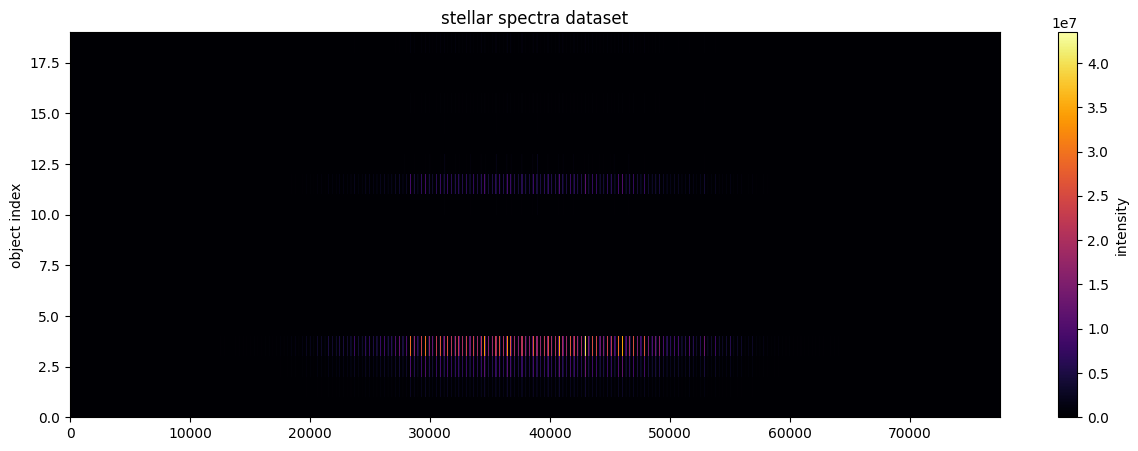

In [3]:
plt.figure(2, figsize=(15, 5))
plt.title("stellar spectra dataset")
plt.pcolormesh(data_2d, cmap="inferno")
plt.colorbar(label="intensity")
plt.ylabel("x")
plt.ylabel("object index")


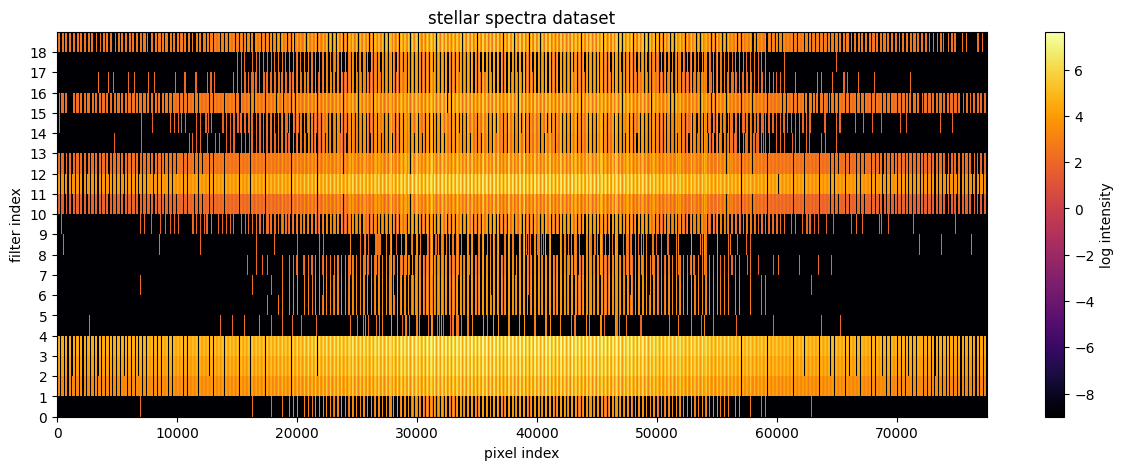

In [4]:
from matplotlib.pyplot import step
log_data = np.log10(data_2d+10e-10)

plt.figure(2, figsize=(15, 5))
plt.title("stellar spectra dataset")
plt.pcolormesh(log_data, cmap="inferno")
plt.colorbar(label="log intensity")
plt.xlabel("pixel index")
plt.ylabel("filter index")

plt.yticks(ticks=np.arange(0, log_data.shape[0], step=1))
plt.show()

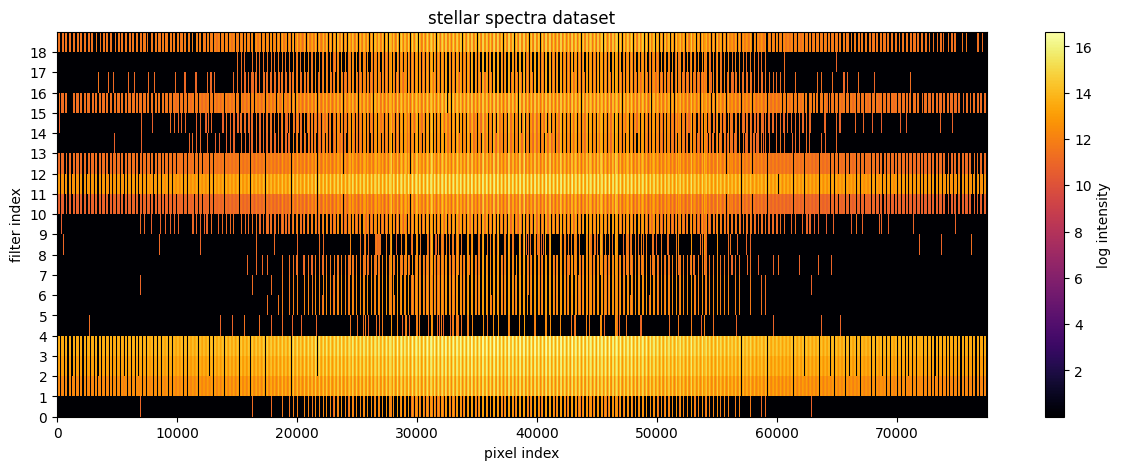

In [5]:
# Add an offset to ensure all values are strictly positive, as required by Sequencer
min_val = np.min(log_data)
if min_val <= 0:
    positive_data = log_data - min_val + 1e-5


plt.figure(2, figsize=(15, 5))
plt.title("stellar spectra dataset")
plt.pcolormesh(positive_data, cmap="inferno")
plt.colorbar(label="log intensity")
plt.xlabel("pixel index")
plt.ylabel("filter index")

plt.yticks(ticks=np.arange(0, log_data.shape[0], step=1))
plt.show()

In [6]:
# Create a simple uniform grid for the feature dimension
grid = np.arange(positive_data.shape[1])
# Define the scales to evaluate
sub_scale_list = [1,2,5,10,15,100]

# Define distance metrics to evaluate
estimator_list = ['EMD']#, 'energy', 'L2', 'KL']

scale_list = [sub_scale_list] * len(estimator_list)

num_of_models = len(estimator_list) * len(sub_scale_list)
num_estimators = int(np.sqrt(num_of_models))    

print("Number of models: ", num_of_models)
print("Number of estimators: ", num_estimators)

seq_out_dir = "sequencer_output"
os.makedirs(seq_out_dir, exist_ok=True)
# Instantiate the Sequencer
seq = sequencer.Sequencer(grid, positive_data, estimator_list, scale_list = None) 
# if scale_list=None then it will use scales of power of 2, until a minimum of 20 pixels per group

Number of models:  6
Number of estimators:  2


In [7]:

final_elongation, final_sequence = seq.execute(seq_out_dir, to_average_N_best_estimators=True, 
                                                number_of_best_estimators=num_estimators,
                                                #to_calculate_distance_matrices=False,
                                                #distance_matrices_inpath= seq_out_dir + "/distance_matrices.pkl",
                                                to_use_parallelization=True,
                                                num_cores=4)

print("Sequencer completed.")
print("Final Elongation:", final_elongation)

Parallelization is ON. Number of cores: 4
calculating the distance matrices for estimator: EMD, scale: 1


finished calculating this distance matrix list, it took: 2.49489164352417 seconds
calculating the distance matrices for estimator: EMD, scale: 2
finished calculating this distance matrix list, it took: 0.5498538017272949 seconds
calculating the distance matrices for estimator: EMD, scale: 4
finished calculating this distance matrix list, it took: 0.6122574806213379 seconds
calculating the distance matrices for estimator: EMD, scale: 8
finished calculating this distance matrix list, it took: 0.6067063808441162 seconds
calculating the distance matrices for estimator: EMD, scale: 16
finished calculating this distance matrix list, it took: 0.8901119232177734 seconds
calculating the distance matrices for estimator: EMD, scale: 32
finished calculating this distance matrix list, it took: 1.560575246810913 seconds
calculating the distance matrices for estimator: EMD, scale: 64
finished calculating this distance matrix list, it took: 2.4284682273864746 seconds
calculating the distance matrices 

/home/dp/Documents/GitHub/sequencer_project/.venv/lib/python3.13/site-packages/sequencer/sequencer_.py:1040: RuntimeWarning: divide by zero encountered in divide
  distance_matrix = 1.0 / proximity_matrix_copy


resulting elongation:  14.296398891966758
intermediate elongations for the different metrics and scales:
metric=EMD, scale=1, elongation: 17.75
metric=EMD, scale=2, elongation: 17.75
metric=EMD, scale=4, elongation: 17.85
metric=EMD, scale=8, elongation: 12.8
metric=EMD, scale=16, elongation: 9.71
metric=EMD, scale=32, elongation: 9.04
metric=EMD, scale=64, elongation: 8.91
metric=EMD, scale=128, elongation: 10.07
metric=EMD, scale=256, elongation: 10.15
metric=EMD, scale=512, elongation: 11.24
metric=EMD, scale=1024, elongation: 10.65
metric=EMD, scale=2048, elongation: 7.95


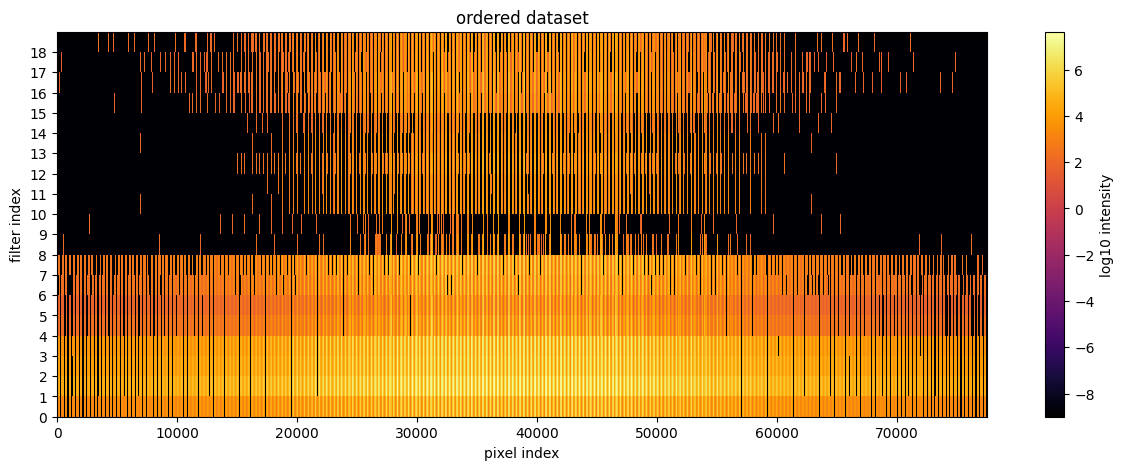

In [8]:


# print the resulting elongation
print("resulting elongation: ", final_elongation)

# print the intermediate elongations for different metrics + scales
estimator_list, scale_list, elongation_list = seq.return_elongation_of_weighted_products_all_metrics_and_scales()

print("intermediate elongations for the different metrics and scales:")
for i in range(len(estimator_list)):
    print("metric=%s, scale=%s, elongation: %s" % (estimator_list[i], 
                                                   scale_list[i], 
                                                   np.round(elongation_list[i], 2)))
    
# plot the ordered dataset
data_reordered = log_data[final_sequence, :]

plt.figure(1, figsize=(15, 5))
plt.title("ordered dataset")
plt.pcolormesh(data_reordered, cmap="inferno")
plt.colorbar(label="log10 intensity")


plt.xlabel("pixel index")
plt.ylabel("filter index")

plt.yticks(ticks=np.arange(0, log_data.shape[0], step=1))
plt.show()